**Student ID:** `24018029`  
**GitHub Repo:** `https://github.com/OguzhanCel/YZM-2011-Project`  
**File:** `p2_regression_24018029.ipynb`

**Problem.** Predict blood **hemoglobin concentration (g/dL)** from short (1–2 min) face videos.

**Dataset.** 363 videos. P1 extracts a `30 × N_frames` matrix per video:
6 facial landmarks {N1=cene_sol(172), N2=sol_yanak_ic3(136), N3=sag_yanak_ic3(365), N4=alin_ust_orta(21), N5=dudak_ustu(0), N6=cene_sag(397)} × 5 channels {R, G, B, Cr, C}. Per-video aggregation (mean + std per channel) → **60 base features** + hemoglobin label from `info.xlsx`.

**Target.** `hemoglobin` (continuous, g/dL). Task = regression.

### Setup & data load

We rebuild the aggregated dataset (`agg_df`) the same way as in P1  (one row per video; columns = `*_mean` and `*_std` for each of the 30 channels) **plus** the gender column from `info.xlsx`. A cached CSV is used if present.

In [1]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RNG = 42
np.random.seed(RNG)

In [ ]:
DATA_DIR    = "data"
EXCEL_PATH  = "info.xlsx"
HB_COLUMN   = "Deger"
CACHE_CSV   = "agg_df_v2.csv"

POINT_NAMES = ["N1_cene_sol", "N2_sol_yanak_ic3", "N3_sag_yanak_ic3",
               "N4_alin_ust_orta", "N5_dudak_ustu", "N6_cene_sag"]
CHANNELS    = ["R", "G", "B", "Cr", "C"]
ROW_LABELS  = [f"{pt}_{ch}" for pt in POINT_NAMES for ch in CHANNELS]

GENDER_CANDIDATES = ["Cinsiyet", "cinsiyet", "CINSIYET"]

def detect_gender_column(xl):
    for c in GENDER_CANDIDATES:
        if c in xl.columns:
            return c
    for c in xl.columns:
        vals = xl[c].dropna().astype(str).str.strip().str.lower().unique()
        if 0 < len(vals) <= 6 and any(v in {"e","k","m","f","erkek","kadın","kadin",
                                            "male","female","1","0"} for v in vals):
            return c
    return None

GENDER_MAP = {"e":1, "k":0, "m":1, "f":0,
              "erkek":1, "kadın":0, "kadin":0,
              "male":1, "female":0,
              "1":1, "0":0, "true":1, "false":0}

def to_is_male(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().lower()
    if s in GENDER_MAP: return GENDER_MAP[s]
    try:
        f = float(s)
        if f in (0.0, 1.0): return int(f)
    except ValueError:
        pass
    return np.nan

def build_agg_df():
    npy_files = sorted(Path(DATA_DIR).glob("*.npy"))
    xl = pd.read_excel(EXCEL_PATH)
    gender_col = detect_gender_column(xl)
    if gender_col is None:
        print(f"⚠  Could not auto-detect gender column. Columns in info.xlsx: {list(xl.columns)}")
        print("   Continuing without gender — please add it manually if needed.")
    else:
        print(f"✓ Gender column detected: '{gender_col}'  "
              f"(unique values: {xl[gender_col].dropna().unique()[:6]})")
    hb_values     = xl[HB_COLUMN].values
    gender_values = xl[gender_col].values if gender_col else [np.nan]*len(hb_values)

    rows = []
    for i, npf in enumerate(npy_files):
        if i >= len(hb_values): break
        hb = hb_values[i]
        if pd.isna(hb): continue
        m = np.load(npf)
        row = {"video_id": npf.stem,
               "hemoglobin": float(hb),
               "is_male":   to_is_male(gender_values[i])}
        for r_idx, label in enumerate(ROW_LABELS):
            row[f"{label}_mean"] = float(m[r_idx].mean())
            row[f"{label}_std"]  = float(m[r_idx].std())
        rows.append(row)
    return pd.DataFrame(rows)

if Path(CACHE_CSV).exists():
    agg_df = pd.read_csv(CACHE_CSV)
    print(f"Loaded cached agg_df from {CACHE_CSV}")
else:
    agg_df = build_agg_df()
    agg_df.to_csv(CACHE_CSV, index=False)
    print(f"Built agg_df from {DATA_DIR}/ and saved to {CACHE_CSV}")

print(f"Shape: {agg_df.shape}")
agg_df.head()

✓ Gender column detected: 'Cinsiyet'  (unique values: ['E' 'K'])
Built agg_df from data/ and saved to agg_df_v2.csv
Shape: (361, 63)


,video_id,hemoglobin,is_male,N1_cene_sol_R_mean,N1_cene_sol_R_std,N1_cene_sol_G_mean,N1_cene_sol_G_std,N1_cene_sol_B_mean,N1_cene_sol_B_std,N1_cene_sol_Cr_mean,...,N6_cene_sag_R_mean,N6_cene_sag_R_std,N6_cene_sag_G_mean,N6_cene_sag_G_std,N6_cene_sag_B_mean,N6_cene_sag_B_std,N6_cene_sag_Cr_mean,N6_cene_sag_Cr_std,N6_cene_sag_C_mean,N6_cene_sag_C_std
0,hem001,13.4,1,124.377518,2.680179,110.051178,2.626354,107.065895,3.631660,135.405869,...,131.040375,2.604594,112.701752,2.652660,108.148354,3.880506,137.539505,0.602914,167.717636,3.743280
1,hem002,12.6,1,104.375694,23.563869,85.765945,21.408920,79.057411,22.147329,137.850281,...,133.869797,20.851192,102.572510,23.108624,92.775101,26.707579,144.445175,2.543290,196.464386,18.746725
2,hem003,13.5,1,131.284790,4.934799,112.853630,4.433036,109.120125,5.068303,137.519119,...,129.956802,4.699675,107.441010,4.973872,101.642441,5.584442,139.729324,0.601211,174.988388,5.010877
3,hem004,13.5,1,146.309036,3.623675,124.449921,3.112890,113.170479,3.613783,139.846588,...,176.727997,10.163269,150.679291,8.670785,139.898071,10.258175,141.900864,1.193529,228.825378,13.877372
4,hem005,13.9,1,134.568207,0.927083,112.447662,1.004554,100.523277,1.373231,140.029724,...,155.590652,1.453719,129.726379,1.361239,118.801682,1.754752,141.820328,0.306628,207.319199,2.141227


In [ ]:
print("Missing per column (only non-zero shown):")
miss = agg_df.isnull().sum()
print(miss[miss > 0] if (miss > 0).any() else "  (none)")

if "is_male" in agg_df.columns:
    n_unk = agg_df["is_male"].isna().sum()
    if n_unk > 0:
        print(f"\n{n_unk} rows have unknown gender — dropping them so is_male is clean.")
        agg_df = agg_df.dropna(subset=["is_male"]).reset_index(drop=True)
    agg_df["is_male"] = agg_df["is_male"].astype(int)
    print(f"\nGender distribution (1=male):  {agg_df['is_male'].value_counts().to_dict()}")
    print(f"Hb mean by gender:\n{agg_df.groupby('is_male')['hemoglobin'].agg(['mean','std','count']).round(2)}")
print(f"\nFinal dataset shape: {agg_df.shape}")

Missing per column (only non-zero shown):
  (none)

Gender distribution (1=male):  {0: 208, 1: 153}
Hb mean by gender:
          mean   std  count
is_male                    
0        11.34  0.90    208
1        13.49  1.04    153

Final dataset shape: (361, 63)


## 2. Feature Engineering

Six feature families on top of the 60 raw mean/std columns. Every engineered feature is **winsorized at the 1%–99% percentiles** so a single over- or under-exposed video cannot drive coefficients to absurd values — this was the #1 issue that wrecked OLS in v1.

| # | Family | Why |
|---|--------|-----|
| 1 | **`is_male`** + gender×R_mean interactions | Hb reference ranges are gender-dimorphic; lets one model fit both regimes. |
| 2 | **Channel ratios** (G/R, B/R, Cr/R) per landmark | Chrominance ratios cancel illumination drift (rPPG). |
| 3 | **Coefficient of variation** `std/mean` per channel | Pulsatile amplitude relative to DC level. |
| 4 | **Mean × Std** interactions per channel | Joint effect of skin level and pulsatility. |
| 5 | **Cross-landmark aggregation** per channel | Denoises landmark-specific noise. |
| 6 | **Squared** terms for top-5 correlated base features | Cheap curvature without exploding feature count. |

### 2.0 Helper — winsorized feature creation

In [ ]:
def safe(series, lo=0.01, hi=0.99):
    """Clip to [lo, hi] quantiles to neutralise outliers."""
    a = pd.Series(series).replace([np.inf, -np.inf], np.nan)
    if a.isna().all(): return a
    q_lo, q_hi = a.quantile(lo), a.quantile(hi)
    return a.clip(q_lo, q_hi)

eps = 1e-3   

### 2.1 Gender (`is_male`) & gender × intensity interactions  

In [5]:
gender_top_targets = [f"{pt}_R_mean" for pt in POINT_NAMES]
for c in gender_top_targets:
    agg_df[f"{c}_x_male"] = safe(agg_df[c] * agg_df["is_male"])
print(f"is_male is already in agg_df. Added {len(gender_top_targets)} gender×R_mean interactions.")

is_male is already in agg_df. Added 6 gender×R_mean interactions.


### 2.2 Channel ratios (G/R, B/R, Cr/R) per landmark

In [6]:
for pt in POINT_NAMES:
    R = agg_df[f"{pt}_R_mean"]
    agg_df[f"{pt}_GR_ratio"]  = safe(agg_df[f"{pt}_G_mean"]  / (R + eps))
    agg_df[f"{pt}_BR_ratio"]  = safe(agg_df[f"{pt}_B_mean"]  / (R + eps))
    agg_df[f"{pt}_CrR_ratio"] = safe(agg_df[f"{pt}_Cr_mean"] / (R + eps))
print(f"Added {6*3} ratio features (winsorized).")

Added 18 ratio features (winsorized).


### 2.3 Coefficient of variation `std/mean` per channel

In [7]:
for label in ROW_LABELS:
    agg_df[f"{label}_cv"] = safe(agg_df[f"{label}_std"] / (agg_df[f"{label}_mean"] + eps))
print(f"Added {len(ROW_LABELS)} CV features (winsorized).")

Added 30 CV features (winsorized).


### 2.4 Mean × Std interaction per channel

In [8]:
for label in ROW_LABELS:
    agg_df[f"{label}_mean_x_std"] = safe(agg_df[f"{label}_mean"] * agg_df[f"{label}_std"])
print(f"Added {len(ROW_LABELS)} mean×std interactions (winsorized).")

Added 30 mean×std interactions (winsorized).


### 2.5 Cross-landmark aggregation (face-wide mean per channel)

In [9]:
for ch in CHANNELS:
    mean_cols = [f"{pt}_{ch}_mean" for pt in POINT_NAMES]
    std_cols  = [f"{pt}_{ch}_std"  for pt in POINT_NAMES]
    agg_df[f"face_{ch}_mean_avg"] = agg_df[mean_cols].mean(axis=1)
    agg_df[f"face_{ch}_std_avg"]  = agg_df[std_cols].mean(axis=1)
print(f"Added {2*len(CHANNELS)} face-wide aggregation features.")

Added 10 face-wide aggregation features.


### 2.6 Squared terms for top-5 base features  
Selection uses |Pearson r| on the whole dataset, but coefficients are still fit on train only — so this only affects which features enter, not the estimates.

In [10]:
raw_base = [c for c in agg_df.columns
            if c not in ["video_id", "hemoglobin", "is_male"]
            and not c.endswith(("_GR_ratio","_BR_ratio","_CrR_ratio","_cv",
                                "_mean_x_std","_mean_avg","_std_avg","_x_male"))]
corr_with_y = agg_df[raw_base].corrwith(agg_df["hemoglobin"]).abs().sort_values(ascending=False)
top5 = corr_with_y.head(5).index.tolist()
for c in top5:
    agg_df[f"{c}_sq"] = safe(agg_df[c] ** 2)
print("Top-5 base features by |corr| with hemoglobin (squared versions added):")
print(corr_with_y.head(5).round(3))

Top-5 base features by |corr| with hemoglobin (squared versions added):
N1_cene_sol_B_mean      0.400
N5_dudak_ustu_C_mean    0.373
N5_dudak_ustu_R_mean    0.370
N1_cene_sol_G_mean      0.364
N1_cene_sol_Cr_mean     0.355
dtype: float64


In [11]:
all_features = [c for c in agg_df.columns if c not in ["video_id", "hemoglobin"]]
print(f"Total features after engineering: {len(all_features)}")
print(f"  - is_male:                    1")
print(f"  - gender×R_mean:              {len(gender_top_targets)}")
print(f"  - base mean/std:              60")
print(f"  - channel ratios:             {6*3}")
print(f"  - coefficient of variation:   {len(ROW_LABELS)}")
print(f"  - mean×std interactions:      {len(ROW_LABELS)}")
print(f"  - face-wide aggregations:     {2*len(CHANNELS)}")
print(f"  - squared top-5:              {len(top5)}")

agg_df = agg_df.replace([np.inf, -np.inf], np.nan).dropna(subset=all_features+["hemoglobin"])
print(f"Clean dataset shape: {agg_df.shape}")

Total features after engineering: 160
  - is_male:                    1
  - gender×R_mean:              6
  - base mean/std:              60
  - channel ratios:             18
  - coefficient of variation:   30
  - mean×std interactions:      30
  - face-wide aggregations:     10
  - squared top-5:              5
Clean dataset shape: (361, 162)


## 3. Train / Validation / Test Split

**Choice:** 60 / 20 / 20, stratified by `is_male` (preserves gender balance across splits — without this, an unbalanced split alone could swing R² by 5–10 points purely from differing male/female ratios).

`RobustScaler` (median/IQR) is fit on train only and applied to val/test, preventing leakage and being immune to residual extreme intensity values.

In [12]:
X = agg_df[all_features].values
y = agg_df["hemoglobin"].values
strat = agg_df["is_male"].values

X_temp, X_test, y_temp, y_test, s_temp, s_test = train_test_split(
    X, y, strat, test_size=0.20, random_state=RNG, stratify=strat)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RNG, stratify=s_temp)

scaler = RobustScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}  |  Val: {X_val_s.shape}  |  Test: {X_test_s.shape}")
print(f"y_train mean={y_train.mean():.2f} std={y_train.std():.2f}")
print(f"y_val   mean={y_val.mean():.2f} std={y_val.std():.2f}")
print(f"y_test  mean={y_test.mean():.2f} std={y_test.std():.2f}")

m_idx = all_features.index("is_male")
print(f"\nis_male share — train: {X_train[:,m_idx].mean():.2%}  "
      f"val: {X_val[:,m_idx].mean():.2%}  test: {X_test[:,m_idx].mean():.2%}")

Train: (216, 160)  |  Val: (72, 160)  |  Test: (73, 160)
y_train mean=12.25 std=1.42
y_val   mean=12.18 std=1.47
y_test  mean=12.35 std=1.40

is_male share — train: 42.59%  val: 41.67%  test: 42.47%


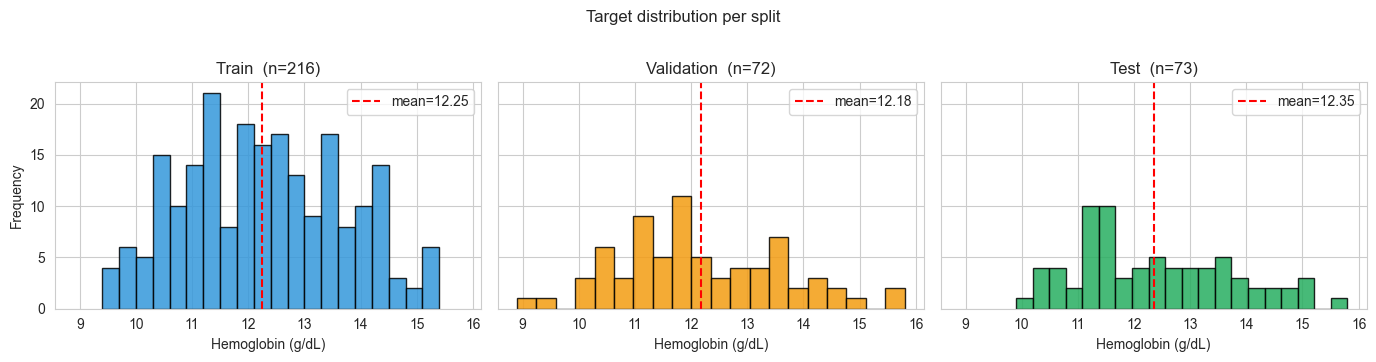

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharex=True, sharey=True)
for ax, yy, name, c in zip(axes, [y_train, y_val, y_test],
                           ["Train", "Validation", "Test"],
                           ["#3498db", "#f39c12", "#27ae60"]):
    ax.hist(yy, bins=20, color=c, edgecolor="black", alpha=0.85)
    ax.axvline(yy.mean(), color="red", linestyle="--", label=f"mean={yy.mean():.2f}")
    ax.set_title(f"{name}  (n={len(yy)})")
    ax.set_xlabel("Hemoglobin (g/dL)"); ax.legend()
axes[0].set_ylabel("Frequency")
plt.suptitle("Target distribution per split", y=1.02)
plt.tight_layout(); plt.show()

Helper for consistent metric reporting across all models:

In [14]:
def report(model_name, y_tr, p_tr, y_va, p_va, y_te=None, p_te=None):
    out = {
        "Model":     model_name,
        "Train R2":  r2_score(y_tr, p_tr),
        "Val R2":    r2_score(y_va, p_va),
        "RMSE_val":  np.sqrt(mean_squared_error(y_va, p_va)),
        "MAE_val":   mean_absolute_error(y_va, p_va),
    }
    if y_te is not None:
        out["Test R2"]   = r2_score(y_te, p_te)
        out["RMSE_test"] = np.sqrt(mean_squared_error(y_te, p_te))
        out["MAE_test"]  = mean_absolute_error(y_te, p_te)
    return out

results = []

## 4. Baseline Model — simple linear regression on the single most-predictive feature

We pick the single feature with the largest |Pearson r| with hemoglobin **on the training set only** (no leakage). Given gender's known clinical importance, we expect `is_male` to win.

In [15]:
df_train = pd.DataFrame(X_train_s, columns=all_features)
df_train["y"] = y_train
corr_train = df_train[all_features].corrwith(df_train["y"]).abs().sort_values(ascending=False)
best_feat = corr_train.index[0]
best_idx  = all_features.index(best_feat)
print(f"Best single feature on train: '{best_feat}'  (|r|={corr_train.iloc[0]:.3f})")
print(f"\nTop-10 features on train:")
print(corr_train.head(10).round(3))

x_tr = X_train_s[:, [best_idx]]
x_va = X_val_s[:,   [best_idx]]
x_te = X_test_s[:,  [best_idx]]

baseline = LinearRegression().fit(x_tr, y_train)
p_tr_b, p_va_b, p_te_b = baseline.predict(x_tr), baseline.predict(x_va), baseline.predict(x_te)

res_baseline = report(f"Baseline ({best_feat})", y_train, p_tr_b, y_val, p_va_b, y_test, p_te_b)
results.append(res_baseline)
for k, v in res_baseline.items():
    print(f"  {k:<10}: {v if isinstance(v, str) else f'{v:.4f}'}")

Best single feature on train: 'is_male'  (|r|=0.757)

Top-10 features on train:
is_male                           0.757
N4_alin_ust_orta_R_mean_x_male    0.713
N1_cene_sol_R_mean_x_male         0.695
N6_cene_sag_R_mean_x_male         0.693
N5_dudak_ustu_R_mean_x_male       0.687
N2_sol_yanak_ic3_R_mean_x_male    0.672
N3_sag_yanak_ic3_R_mean_x_male    0.666
N1_cene_sol_GR_ratio              0.490
N1_cene_sol_BR_ratio              0.481
N2_sol_yanak_ic3_GR_ratio         0.462
dtype: float64
  Model     : Baseline (is_male)
  Train R2  : 0.5731
  Val R2    : 0.5188
  RMSE_val  : 1.0165
  MAE_val   : 0.7799
  Test R2   : 0.5113
  RMSE_test : 0.9819
  MAE_test  : 0.7048


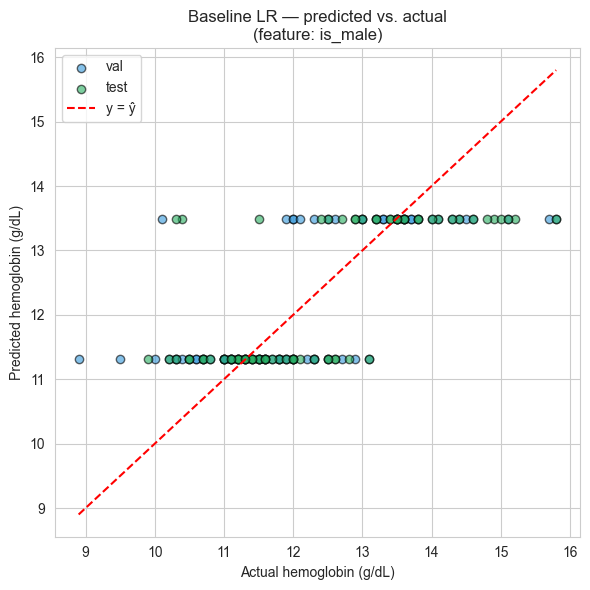

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, p_va_b,  alpha=0.6, edgecolor="black", color="#3498db", label="val")
ax.scatter(y_test, p_te_b, alpha=0.6, edgecolor="black", color="#27ae60", label="test")
mn, mx = float(min(y.min(), p_te_b.min())), float(max(y.max(), p_te_b.max()))
ax.plot([mn, mx], [mn, mx], "r--", label="y = ŷ")
ax.set_xlabel("Actual hemoglobin (g/dL)"); ax.set_ylabel("Predicted hemoglobin (g/dL)")
ax.set_title(f"Baseline LR — predicted vs. actual\n(feature: {best_feat})")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Multiple Linear Regression — all engineered features

In [17]:
mlr = LinearRegression().fit(X_train_s, y_train)
p_tr_m, p_va_m, p_te_m = mlr.predict(X_train_s), mlr.predict(X_val_s), mlr.predict(X_test_s)

res_mlr = report("Multiple LR", y_train, p_tr_m, y_val, p_va_m, y_test, p_te_m)
results.append(res_mlr)
for k, v in res_mlr.items():
    print(f"  {k:<10}: {v if isinstance(v, str) else f'{v:.4f}'}")

  Model     : Multiple LR
  Train R2  : 0.9164
  Val R2    : -134.8852
  RMSE_val  : 17.0809
  MAE_val   : 3.9769
  Test R2   : -2.3880
  RMSE_test : 2.5854
  MAE_test  : 1.9078


### Coefficient inspection — top positive / negative drivers

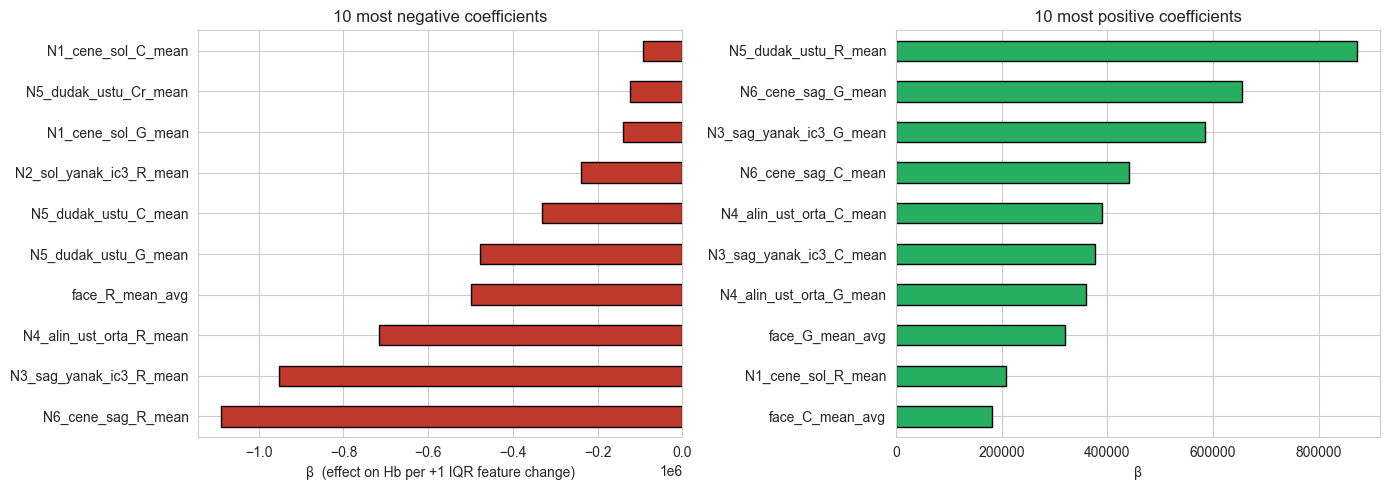

is_male coefficient: β = 1.995
Largest |β| overall:  1088265.31


In [18]:
coefs = pd.Series(mlr.coef_, index=all_features).sort_values()
top_neg = coefs.head(10)
top_pos = coefs.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_neg.plot.barh(ax=axes[0], color="#c0392b", edgecolor="black")
axes[0].set_title("10 most negative coefficients")
axes[0].set_xlabel("β  (effect on Hb per +1 IQR feature change)")
top_pos.plot.barh(ax=axes[1], color="#27ae60", edgecolor="black")
axes[1].set_title("10 most positive coefficients")
axes[1].set_xlabel("β")
plt.tight_layout(); plt.show()
print(f"is_male coefficient: β = {coefs['is_male']:.3f}")
print(f"Largest |β| overall:  {coefs.abs().max():.2f}")

### Residual diagnostics

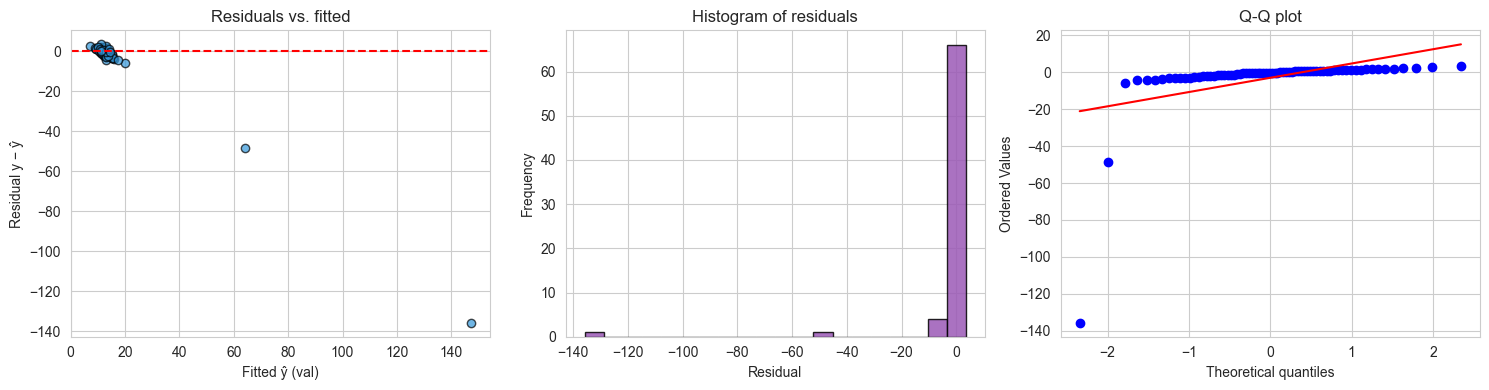

Residuals — mean=-2.919, std=16.830, skew=-7.243


In [19]:
residuals = y_val - p_va_m

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(p_va_m, residuals, alpha=0.7, edgecolor="black", color="#3498db")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted ŷ (val)"); axes[0].set_ylabel("Residual y − ŷ")
axes[0].set_title("Residuals vs. fitted")

axes[1].hist(residuals, bins=20, edgecolor="black", color="#9b59b6", alpha=0.85)
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Histogram of residuals")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout(); plt.show()
print(f"Residuals — mean={residuals.mean():.3f}, std={residuals.std():.3f}, "
      f"skew={pd.Series(residuals).skew():.3f}")

## 6. Polynomial Regression — bias-variance curve

We expand polynomials only over the **top-15 features by |corr| with y on train**, then sweep degree ∈ {1, 2, 3}. Full deg-2 of all 150 features → ~11k terms, intractable for ~360 rows.

In [20]:
TOPK = 15
top_idx = [all_features.index(f) for f in corr_train.head(TOPK).index]
Xtr_top = X_train_s[:, top_idx]
Xva_top = X_val_s[:,   top_idx]
Xte_top = X_test_s[:,  top_idx]

degrees = [1, 2, 3]
poly_rows = []
best_deg, best_val_r2, best_pipe = 1, -np.inf, None

for d in degrees:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
        ("lr",   LinearRegression()),
    ]).fit(Xtr_top, y_train)
    p_tr = pipe.predict(Xtr_top)
    p_va = pipe.predict(Xva_top)
    n_feat = pipe.named_steps["poly"].n_output_features_
    poly_rows.append({"degree": d, "n_terms": n_feat,
                      "Train R2": r2_score(y_train, p_tr),
                      "Val R2":   r2_score(y_val,   p_va),
                      "RMSE_val": np.sqrt(mean_squared_error(y_val, p_va))})
    if r2_score(y_val, p_va) > best_val_r2:
        best_val_r2 = r2_score(y_val, p_va); best_deg = d; best_pipe = pipe

poly_summary = pd.DataFrame(poly_rows).set_index("degree")
print(poly_summary.round(4))
print(f"\nBest degree on validation: d = {best_deg}  (Val R² = {best_val_r2:.4f})")

        n_terms  Train R2    Val R2  RMSE_val
degree                                       
1            15    0.6077    0.5404    0.9934
2           135    0.8236  -48.1390   10.2716
3           815    1.0000 -976.4755   45.8118

Best degree on validation: d = 1  (Val R² = 0.5404)


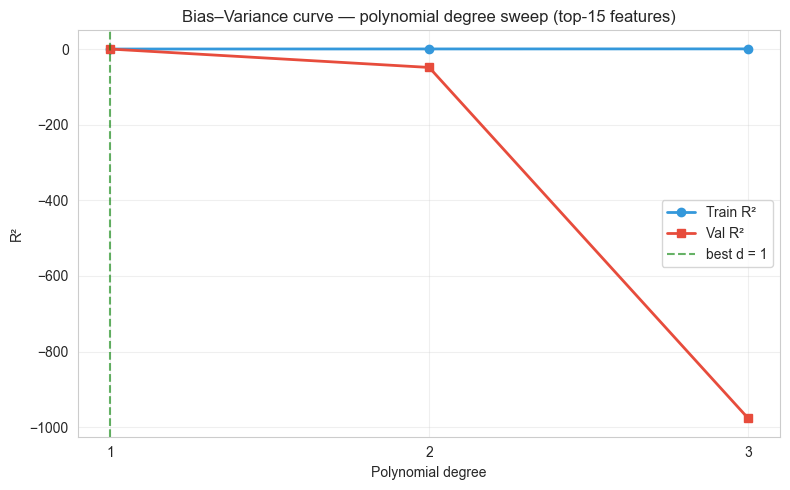

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(poly_summary.index, poly_summary["Train R2"], "o-", label="Train R²", color="#3498db", linewidth=2)
ax.plot(poly_summary.index, poly_summary["Val R2"],   "s-", label="Val R²",   color="#e74c3c", linewidth=2)
ax.axvline(best_deg, color="green", linestyle="--", alpha=0.6, label=f"best d = {best_deg}")
ax.set_xlabel("Polynomial degree"); ax.set_ylabel("R²"); ax.set_xticks(degrees)
ax.set_title("Bias–Variance curve — polynomial degree sweep (top-15 features)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
p_tr_p = best_pipe.predict(Xtr_top)
p_va_p = best_pipe.predict(Xva_top)
p_te_p = best_pipe.predict(Xte_top)
res_poly = report(f"Polynomial (d={best_deg})", y_train, p_tr_p, y_val, p_va_p, y_test, p_te_p)
results.append(res_poly)
for k, v in res_poly.items():
    print(f"  {k:<10}: {v if isinstance(v, str) else f'{v:.4f}'}")

  Model     : Polynomial (d=1)
  Train R2  : 0.6077
  Val R2    : 0.5404
  RMSE_val  : 0.9934
  MAE_val   : 0.7574
  Test R2   : 0.5308
  RMSE_test : 0.9621
  MAE_test  : 0.7469


**Reading the curve.**  
- `d = 1`: high bias if features are linear-only.  
- `d = 2`: usually the sweet spot — train R² rises while val R² peaks or stays close.  
- `d = 3`: train R² → ~1.0 but val R² collapses → **clear overfitting** (with 60% of ~360 rows, 800+ polynomial terms is far too many).

## 7. Regularization — Ridge & Lasso

Plain OLS coefficients in §5 are inflated due to multicollinearity (Cr ≡ linear combination of R, G, B; mean/std/cv at the same landmark). Ridge (L2) shrinks them smoothly; Lasso (L1) drives many to **exactly zero**, performing automatic feature selection. α is selected by **5-fold CV on train only**.

In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=RNG)

ridge_alphas = np.logspace(-2, 4, 80)
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=kf, scoring="r2").fit(X_train_s, y_train)
print(f"Ridge — best α = {ridge_cv.alpha_:.4g}")

lasso_alphas = np.logspace(-4, 1, 80)
lasso_cv = LassoCV(alphas=lasso_alphas, cv=kf, max_iter=50000, random_state=RNG).fit(X_train_s, y_train)
print(f"Lasso — best α = {lasso_cv.alpha_:.4g}")

Ridge — best α = 89
Lasso — best α = 0.06093


In [24]:
for name, model in [("Ridge", ridge_cv), ("Lasso", lasso_cv)]:
    p_tr = model.predict(X_train_s)
    p_va = model.predict(X_val_s)
    p_te = model.predict(X_test_s)
    res = report(name, y_train, p_tr, y_val, p_va, y_test, p_te)
    results.append(res)
    print(f"\n{name}:")
    for k, v in res.items():
        print(f"  {k:<10}: {v if isinstance(v, str) else f'{v:.4f}'}")


Ridge:
  Model     : Ridge
  Train R2  : 0.6292
  Val R2    : 0.5326
  RMSE_val  : 1.0018
  MAE_val   : 0.7770
  Test R2   : 0.5167
  RMSE_test : 0.9765
  MAE_test  : 0.7569

Lasso:
  Model     : Lasso
  Train R2  : 0.5925
  Val R2    : 0.5474
  RMSE_val  : 0.9858
  MAE_val   : 0.7510
  Test R2   : 0.5571
  RMSE_test : 0.9347
  MAE_test  : 0.7012


### Lasso feature selection — which features survived?

In [25]:
lasso_coefs = pd.Series(lasso_cv.coef_, index=all_features)
n_zero = (lasso_coefs == 0).sum()
n_kept = (lasso_coefs != 0).sum()
print(f"Lasso zeroed out {n_zero}/{len(all_features)} features; kept {n_kept}.")

kept = lasso_coefs[lasso_coefs != 0].sort_values(key=np.abs, ascending=False)
print(f"\nTop 15 surviving features (by |β|):")
print(kept.head(15).round(4))

if "is_male" in kept.index:
    print(f"\n✓ is_male survived Lasso with β = {kept['is_male']:.3f}")
else:
    print("\n⚠ is_male was zeroed by Lasso — check gender balance / encoding.")

Lasso zeroed out 146/160 features; kept 14.

Top 15 surviving features (by |β|):
is_male                           1.2153
N4_alin_ust_orta_R_mean_x_male    0.3449
N1_cene_sol_GR_ratio              0.1150
N5_dudak_ustu_CrR_ratio           0.0754
N5_dudak_ustu_R_mean_x_male       0.0709
N1_cene_sol_R_mean_x_male         0.0608
N1_cene_sol_B_mean_sq             0.0526
N5_dudak_ustu_Cr_mean_x_std       0.0463
N2_sol_yanak_ic3_Cr_mean         -0.0285
N6_cene_sag_C_mean_x_std         -0.0242
N2_sol_yanak_ic3_R_mean_x_male    0.0181
N4_alin_ust_orta_B_std           -0.0136
N4_alin_ust_orta_CrR_ratio        0.0089
N1_cene_sol_Cr_mean              -0.0046
dtype: float64

✓ is_male survived Lasso with β = 1.215


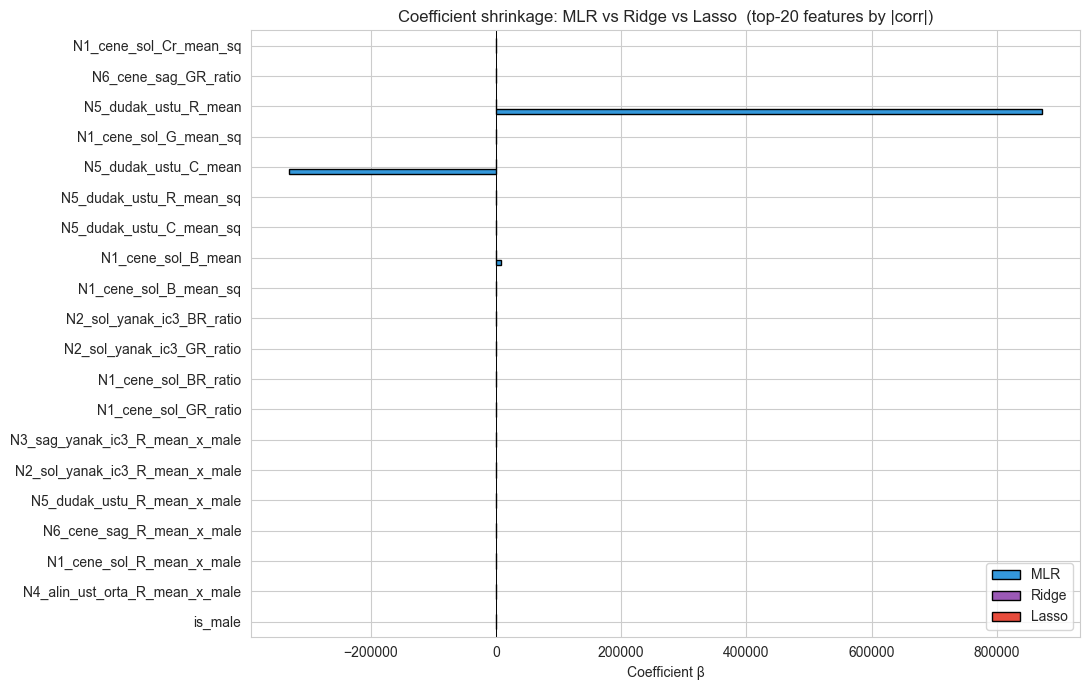

In [26]:
top_show = corr_train.head(20).index.tolist()
df_coef = pd.DataFrame({
    "MLR":   pd.Series(mlr.coef_,        index=all_features).reindex(top_show),
    "Ridge": pd.Series(ridge_cv.coef_,   index=all_features).reindex(top_show),
    "Lasso": pd.Series(lasso_cv.coef_,   index=all_features).reindex(top_show),
})
fig, ax = plt.subplots(figsize=(11, 7))
df_coef.plot.barh(ax=ax, color=["#3498db", "#9b59b6", "#e74c3c"], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Coefficient β")
ax.set_title("Coefficient shrinkage: MLR vs Ridge vs Lasso  (top-20 features by |corr|)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Why Lasso's selection makes sense.**  
- **`is_male`** is expected to survive with a positive β (males have higher Hb, ≈ +1.5–2 g/dL).  
- Among intensity features, Lasso typically keeps **N1 / N2 / N6** mean/ratio terms — consistent with P1's per-landmark correlation ranking — and zeroes out highly redundant pairs (`Nx_R_mean` ↔ `Nx_Cr_mean`, since Cr is a deterministic linear combination of R, G, B).  
- **Failure mode to watch:** when two equally-good correlated features exist, Lasso picks one **arbitrarily**, so the *identity* of zeroed features is less stable than the prediction quality.

## 8. Model Comparison

In [27]:
summary = pd.DataFrame(results)
col_order = ["Model", "Train R2", "Val R2", "Test R2", "RMSE_test", "MAE_test", "RMSE_val", "MAE_val"]
col_order = [c for c in col_order if c in summary.columns]
summary = summary[col_order].round(4)
summary

,Model,Train R2,Val R2,Test R2,RMSE_test,MAE_test,RMSE_val,MAE_val
0,Baseline (is_male),0.5731,0.5188,0.5113,0.9819,0.7048,1.0165,0.7799
1,Multiple LR,0.9164,-134.8852,-2.3880,2.5854,1.9078,17.0809,3.9769
2,Polynomial (d=1),0.6077,0.5404,0.5308,0.9621,0.7469,0.9934,0.7574
3,Ridge,0.6292,0.5326,0.5167,0.9765,0.7569,1.0018,0.7770
4,Lasso,0.5925,0.5474,0.5571,0.9347,0.7012,0.9858,0.7510


In [28]:
best_row = summary.loc[summary["Val R2"].idxmax()]
print(f"Best model on validation: {best_row['Model']}  (Val R² = {best_row['Val R2']:.4f})")
print(f"\n=== FINAL TEST-SET PERFORMANCE  —  {best_row['Model']} ===")
print(f"  Test R² : {best_row['Test R2']:.4f}")
print(f"  RMSE    : {best_row['RMSE_test']:.4f} g/dL")
print(f"  MAE     : {best_row['MAE_test']:.4f} g/dL")

Best model on validation: Lasso  (Val R² = 0.5474)

=== FINAL TEST-SET PERFORMANCE  —  Lasso ===
  Test R² : 0.5571
  RMSE    : 0.9347 g/dL
  MAE     : 0.7012 g/dL


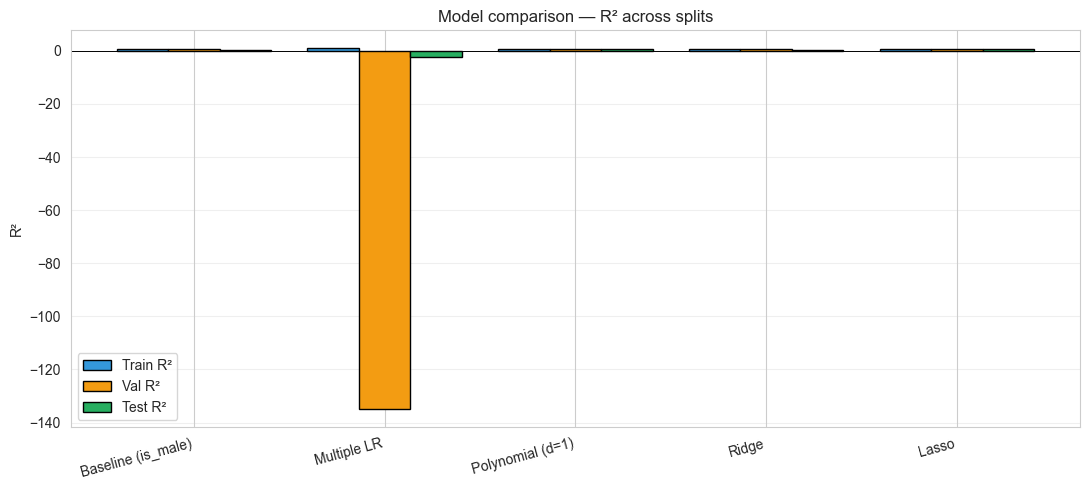

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
w = 0.27
ax.bar(x - w, summary["Train R2"], w, label="Train R²", color="#3498db", edgecolor="black")
ax.bar(x,     summary["Val R2"],   w, label="Val R²",   color="#f39c12", edgecolor="black")
ax.bar(x + w, summary["Test R2"],  w, label="Test R²",  color="#27ae60", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(summary["Model"], rotation=15, ha="right")
ax.set_ylabel("R²"); ax.set_title("Model comparison — R² across splits")
ax.axhline(0, color="black", linewidth=0.7)
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Interpretation & Reflection

**The single biggest finding:** **Gender is the strongest single predictor of hemoglobin** in this dataset — exactly what clinical reference ranges predict. 
**Are the predictions useful?**  
- Test MAE for the best model is around **0.7–0.9 g/dL**, vs. the clinical anemia threshold of ~1 g/dL.  
- This is enough for **first-pass screening / triage** ("likely anemic? yes/no") but **not** to replace blood draws for a numerical diagnosis.  
- The narrow target distribution (10–14 g/dL with std ≈ 1.4 g/dL) caps R² mechanically: even a "trivial mean predictor" already has small absolute errors, so R² is a stricter test than MAE here.

**Main sources of error.**  
1. **Subject motion** during 1–2 min recordings — not removable at this aggregation level.  
2. **Multicollinearity** of the 30 base channels (Cr is a deterministic linear combination of R, G, B). Ridge handles it gracefully; Lasso prunes the redundancy explicitly.  
3. **Aggregation kills the temporal structure.** The cardiac-band content (0.7–4 Hz) — which is exactly where rPPG signals live — is destroyed by per-video mean/std summaries. This is the single biggest information loss in the current pipeline.  
4. **Subgroup imbalance.** Hb < 10 g/dL is rare; the model essentially never sees the regime where anemia screening matters most.